# Foundations of LLMs — Hands-on Notebook
**GenAI-Health Karyashala | Darshna Parmar**

This notebook demonstrates tokenization, embeddings, attention intuition, prompt engineering, in-context learning, and a mini RAG pipeline.

## Setup

In [ ]:
!pip -q install transformers sentence-transformers faiss-cpu scikit-learn

In [ ]:
# =========================================================
# LLM Hands-on Workshop: Required Library Installation
# =========================================================
# This cell installs all required libraries for:
# - tokenization
# - embeddings
# - attention demo
# - prompt engineering
# - mini RAG pipeline
# =========================================================

# Install Hugging Face transformers (tokenizers, GPT demo)
!pip -q install transformers

# Install sentence-transformers (for embedding similarity & RAG)
!pip -q install sentence-transformers

# Install scikit-learn (for cosine similarity)
!pip -q install scikit-learn

# Install matplotlib (for visualizations)
!pip -q install matplotlib

# All
!pip -q install transformers sentence-transformers scikit-learn matplotlib

# Optional: FAISS for scalable vector search (not mandatory)
# !pip -q install faiss-cpu

In [ ]:
# =========================================================
# Import Required Libraries
# =========================================================

import numpy as np
# NumPy: used for numerical operations and array handling
# (e.g., attention scaling, vector math)

import torch
# PyTorch: used for tensor computations in the attention demo
# (LLMs internally operate on tensors)

import matplotlib.pyplot as plt
# Matplotlib: used for all visualizations
# (token plots, comparison charts, etc.)

import string
# Built-in Python module providing string utilities
# Used here for punctuation detection in word-level tokenization demo

from transformers import AutoTokenizer, pipeline
# AutoTokenizer: performs subword tokenization (WordPiece/BPE)
# pipeline: used for quick text generation demo (prompt engineering)

from sentence_transformers import SentenceTransformer
# SentenceTransformer: generates dense embeddings
# Used for semantic similarity and mini RAG retrieval

from sklearn.metrics.pairwise import cosine_similarity
# cosine_similarity: computes similarity between embedding vectors
# Used in embedding comparison and retrieval steps

## 🔹 1. Tokenization Demo

### Word-Level Tokenization
Goal: Demonstrate how text is split into full words and understand its practical limitations.

Description:
Word-level tokenization segments a sentence into complete words using whitespace as the primary boundary. It is simple and human-readable, but it can lead to very large vocabularies and struggles with unseen or rare words.

Key Observation:

*   Tokens correspond closely to words
*   Sequence length is short
*   Punctuation may remain attached
*   Rare words cannot be decomposed
*   Leads to vocabulary explosion


Word-level tokens:
['i', 'am', 'an', 'nlp', 'researcher', 'working', 'on', 'genai.']
Token count: 8


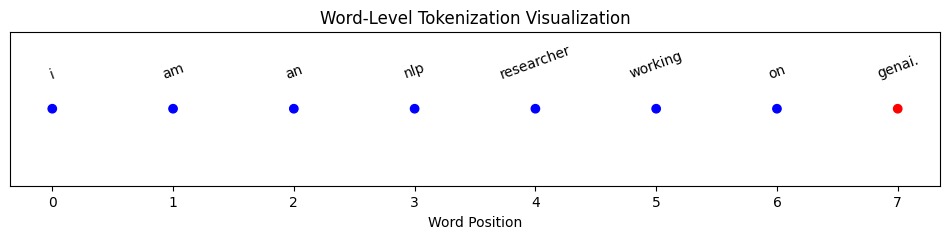

In [ ]:
# Input text
text = "I am an NLP Researcher working on GenAI." ## Try: 1) Patient has high fever and headache. 2) Patient has fever for 3 days and severe headaches.

# Split text into word-level tokens (lowercased)
# .split() separates on whitespace
word_tokens = text.lower().split()

# Print tokens and count
print("Word-level tokens:")
print(word_tokens)
print("Token count:", len(word_tokens))


# ---------------- VISUALIZATION ----------------

# Create a wide figure for readability
plt.figure(figsize=(12, 2))

# Assign colors:
# blue = normal words
# red = tokens containing punctuation
# green = capital-origin words (informational — optional logic)

colors = []
for tok in word_tokens:
    if any(p in tok for p in string.punctuation):
        colors.append("red")          # punctuation attached
    elif tok.isalpha():
        colors.append("blue")         # clean word
    else:
        colors.append("green")        # mixed token (rare cases)

# Plot token positions
plt.scatter(range(len(word_tokens)), [1]*len(word_tokens), c=colors)

# Annotate tokens above points
for i, tok in enumerate(word_tokens):
    plt.text(i, 1.02, tok, ha='center', va='bottom', rotation=20)

# Remove y-axis (not meaningful)
plt.yticks([])

# Label x-axis
plt.xlabel("Word Position")

# Add title
plt.title("Word-Level Tokenization Visualization")

# Show plot
plt.show()

### Character-Level Tokenization
Goal: Demonstrate how text is split into individual characters and understand its trade-offs.

Description:
Character-level tokenization decomposes a sentence into individual characters, including letters, spaces, and punctuation. This approach eliminates the out-of-vocabulary (OOV) problem because every possible word can be represented as a sequence of known characters. However, it significantly increases sequence length and may reduce semantic efficiency.

Key Observation:

*   Tokens correspond to individual characters
*   Sequence length becomes very long
*   Spaces and punctuation are treated as tokens
*   Completely avoids OOV issues
*   May reduce modeling efficiency due to longer sequences

Character-level tokens:
['i', ' ', 'a', 'm', ' ', 'a', 'n', ' ', 'n', 'l', 'p', ' ', 'r', 'e', 's', 'e', 'a', 'r', 'c', 'h', 'e', 'r', ' ', 'w', 'o', 'r', 'k', 'i', 'n', 'g', ' ', 'o', 'n', ' ', 'g', 'e', 'n', 'a', 'i', '.']
Token count: 40


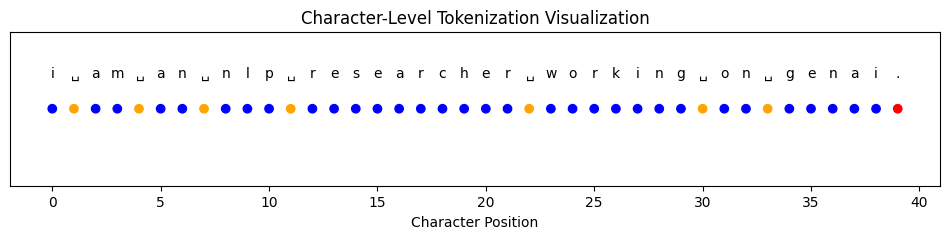

In [ ]:
# Input text
text = "I am an NLP Researcher working on GenAI." ## Try: 1) Patient has high fever and headache. 2) Patient has fever for 3 days and severe headaches.

# Convert text into character-level tokens (lowercased)
char_tokens = list(text.lower())

# Print tokens and count
print("Character-level tokens:")
print(char_tokens)
print("Token count:", len(char_tokens))


# ---------------- VISUALIZATION ----------------

# Create a wide figure for better readability
plt.figure(figsize=(12, 2))

# Assign colors:
# blue = alphabet characters
# orange = space
# red = punctuation
colors = []
for ch in char_tokens:
    if ch == " ":
        colors.append("orange")      # highlight spaces
    elif ch.isalpha():
        colors.append("blue")        # normal letters
    else:
        colors.append("red")         # punctuation

# Plot each character position as a dot
plt.scatter(range(len(char_tokens)), [1]*len(char_tokens), c=colors)

# Annotate each character above its position
for i, ch in enumerate(char_tokens):
    display_char = ch if ch != " " else "␣"  # show space symbol clearly
    plt.text(i, 1.02, display_char, ha='center', va='bottom')

# Remove y-axis (not meaningful here)
plt.yticks([])

# Label x-axis
plt.xlabel("Character Position")

# Add title
plt.title("Character-Level Tokenization Visualization")

# Display the plot
plt.show()
import torch
from transformers import AutoTokenizer, pipeline
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

### Subword Tokenization (WordPiece/BPE(Byte Pair Encoding))
1. BPE: BPE is a subword tokenization algorithm that splits words into frequently occurring character pairs to handle rare and unknown words.
* Reduces OOV (Out Of Vocabulary) problems
* Keeps vocabulary size manageable
* Handles rare and medical terms better
* Used in GPT-2, GPT-3 tokenizers

e.g. researcher → research + er
e.g. thrombocytopenia → thrombo + cyto + penia

BPE → GPT / RoBERTa family
BPE is used in:

* GPT-2
* GPT-3 (variant)
* RoBERTa
* LLaMA (BPE-style)

2. WordPiece: WordPiece breaks words into smaller pieces based on statistical likelihood so models can handle rare and unseen words.
* It is widely used in BERT-family models.
* Reduces OOV (Out Of Vocabulary) problems
* Keeps vocabulary manageable
* Handles rare/medical terms
* Improves language understanding

e.g. Researcher → ["research", "##er"]
e.g. thrombocytopenia → ["thrombo", "##cyto", "##penia"]

WordPiece → BERT family
WordPiece is used in:

* BERT
* BioBERT
* ClinicalBERT
* DistilBERT

Goal: Demonstrate how rare or complex words are decomposed into meaningful subword units while maintaining an efficient vocabulary.

Description:
Subword tokenization splits text into statistically learned sub-units rather than full words or individual characters. Common words are often kept intact, while rare or morphologically complex words are broken into smaller reusable pieces (e.g., WordPiece or BPE). This approach balances vocabulary size and sequence length, making it the preferred choice for modern Large Language Models.

Key Observation:

*   Common words often remain whole
*   Rare or compound words are split into subwords
*   Vocabulary size remains manageable
*   Sequence length is moderate
*   Effectively mitigates the OOV problem
*   Widely used in modern LLMs (BERT, GPT, etc.)

Text: I am an NLP researcher working on GenAI.
Tokens: ['i', 'am', 'an', 'nl', '##p', 'researcher', 'working', 'on', 'gen', '##ai', '.']
Token IDs: [1045, 2572, 2019, 17953, 2361, 10753, 2551, 2006, 8991, 4886, 1012]
Token count: 11


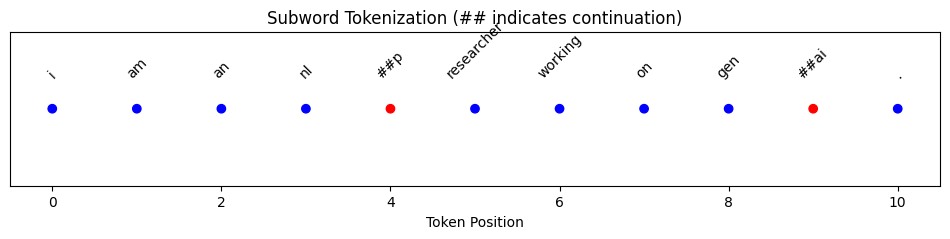

In [ ]:
# Load pretrained tokenizer (WordPiece used in BERT)
## Try: 1) Patient has high fever and headache. 2) Patient has fever for 3 days and severe headaches.
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased') # wordpiece - bert-base-uncased, Try: gpt2 (BPE),

# Input sentence to be tokenized
text = 'I am an NLP researcher working on GenAI.'

# Perform subword tokenization
# Rare/unknown words may be split into pieces with '##'
tokens = tokenizer.tokenize(text)

# Convert tokens into vocabulary IDs used by the model
ids = tokenizer.convert_tokens_to_ids(tokens)

# Display original text
print('Text:', text)

# Display tokenized output
print('Tokens:', tokens)

# Display corresponding token IDs
print('Token IDs:', ids)

# Display number of tokens produced
print('Token count:', len(tokens))


# ---------------- VISUALIZATION ----------------

# Create a wide figure for readability
plt.figure(figsize=(12, 2))

# Assign colors to tokens:
# blue = start of a word
# red = continuation subword (## prefix)
colors = ["red" if tok.startswith("##") else "blue" for tok in tokens]

# Plot token positions along a horizontal line
plt.scatter(range(len(tokens)), [1]*len(tokens), c=colors)

# Annotate each token above its position
for i, tok in enumerate(tokens):
    plt.text(i, 1.02, tok, ha='center', va='bottom', rotation=45)

# Remove y-axis since it has no semantic meaning here
plt.yticks([])

# Label x-axis to indicate token order
plt.xlabel("Token Position")

# Add informative title
plt.title("Subword Tokenization (## indicates continuation)")

# Render the visualization
plt.show()

In [ ]:
from transformers import AutoTokenizer

bpe_tokenizer = AutoTokenizer.from_pretrained("gpt2")

text = "I am an NLP researcher working on GenAI."
print(bpe_tokenizer.tokenize(text))

['I', 'Ġam', 'Ġan', 'ĠN', 'LP', 'Ġresearcher', 'Ġworking', 'Ġon', 'ĠGen', 'AI', '.', 'ĠGreat']


In [ ]:
from transformers import AutoTokenizer

## Try: 1) Patient has high fever and headache. 2) Patient has fever for 3 days and severe headaches.
text = "I am an NLP researcher working on GenAI. I love transformers."

models = [
    "bert-base-uncased",        # WordPiece
    "gpt2",                     # BPE
    "t5-small",                 # SentencePiece (Unigram)
    "roberta-base",             # byte-level BPE
    "facebook/bart-base"        # BPE seq2seq
]

for m in models:
    tokenizer = AutoTokenizer.from_pretrained(m)
    tokens = tokenizer.tokenize(text)

    print(f"\n{'='*60}")
    print(f"Model: {m}")
    print(f"Tokenizer type: {tokenizer.__class__.__name__}")
    print("Tokens:", tokens)
    print("Token count:", len(tokens))


Model: bert-base-uncased
Tokenizer type: BertTokenizer
Tokens: ['i', 'am', 'an', 'nl', '##p', 'researcher', 'working', 'on', 'gen', '##ai', '.', 'i', 'love', 'transformers', '.']
Token count: 15

Model: gpt2
Tokenizer type: GPT2Tokenizer
Tokens: ['I', 'Ġam', 'Ġan', 'ĠN', 'LP', 'Ġresearcher', 'Ġworking', 'Ġon', 'ĠGen', 'AI', '.', 'ĠI', 'Ġlove', 'Ġtransform', 'ers', '.']
Token count: 16

Model: t5-small
Tokenizer type: T5Tokenizer
Tokens: ['▁I', '▁am', '▁an', '▁N', 'LP', '▁researcher', '▁working', '▁on', '▁Gen', 'AI', '.', '▁I', '▁love', '▁transformer', 's', '.']
Token count: 16

Model: roberta-base
Tokenizer type: RobertaTokenizer
Tokens: ['I', 'Ġam', 'Ġan', 'ĠN', 'LP', 'Ġresearcher', 'Ġworking', 'Ġon', 'ĠGen', 'AI', '.', 'ĠI', 'Ġlove', 'Ġtransform', 'ers', '.']
Token count: 16

Model: facebook/bart-base
Tokenizer type: RobertaTokenizer
Tokens: ['I', 'Ġam', 'Ġan', 'ĠN', 'LP', 'Ġresearcher', 'Ġworking', 'Ġon', 'ĠGen', 'AI', '.', 'ĠI', 'Ġlove', 'Ġtransform', 'ers', '.']
Token count: 16


| Model       | Tokenization Method     | Special Marker | Marker Meaning                     | Token Count |
| ----------- | ----------------------- | -------------- | ---------------------------------- | ----------- |
| **BERT**    | WordPiece               | `##`           | Word continuation (subword suffix) | 15          |
| **GPT-2**   | BPE                     | `Ġ`            | Leading whitespace before token    | 16          |
| **T5**      | Unigram (SentencePiece) | `▁`            | Beginning of a new word            | 16          |
| **RoBERTa** | byte-level BPE          | `Ġ`            | Leading whitespace before token    | 16          |
| **BART**    | byte-level BPE          | `Ġ`            | Leading whitespace before token    | 16          |


### Learning:
*  Word-level → intuitive but limited
*  Character-level → complete but inefficient
*  Subword → balanced (modern solution)

### Task 1 — Predict the Tokenization

Sentence:

*  Transformers are amazing!
*  Patients with dengue often experience high fever.

Questions:

1.   Write the expected word-level tokens.
2.   Do you think any word will split in WordPiece tokenization? Why?
3.  Will the token count be equal to, less than, or greater than the number of words?

### Task 2 — Multi-Model Tokenizer Comparison

Run the tokenizer for the following sentence:
1. text = "I love working with multilingual models."
2. text = "The patient was diagnosed with hypertension."
Models to test:

*  bert-base-uncased
*  gpt2
*  t5-small

Fill the table:
| Model | Token Count | Special Marker Observed | Tokenizer Type |
| ----- | ----------- | ----------------------- | -------------- |
Questions

1.  Which model produced the fewest tokens?
2.  Which special marker did you observe for each model?
3.  Which tokenizer explicitly encodes whitespace?
4.  Are token boundaries identical across models? Explain briefly.

### Task 3 — Marker Identification Challenge

Given the following token outputs:
* ['gen', '##ai']
* ['Ġresearch']
* ['▁multi', 'lingual']
* ['hyper', '##tension']
* ['Ġpatient']

Questions

For each case, identify:
1. The tokenization method
2. What the marker indicates
3. One model family that likely uses it

## 🔹 2. Embedding Similarity
Embeddings are dense numerical vector representations of text (words, sentences, or documents) that capture semantic meaning in a continuous vector space.

In [ ]:
# Required for sentence embeddings (if not already installed)
!pip -q install sentence-transformers scikit-learn

from sentence_transformers import SentenceTransformer
# SentenceTransformer: loads pretrained embedding model

from sklearn.metrics.pairwise import cosine_similarity
# cosine_similarity: computes semantic similarity between vectors

In [ ]:
# Load pretrained sentence embedding model
# all-MiniLM-L6-v2 is lightweight and fast
model = SentenceTransformer('all-MiniLM-L6-v2')

# Words whose semantic similarity we want to compare
words = ['researcher', 'scientist', 'banana', 'AI', 'NLP'] ##Try ['cardiologist', 'heart specialist', 'myocardial infarction', 'heart attack', 'banana']

# Convert words into dense vector embeddings
# Output shape: (num_words, embedding_dim)
embeddings = model.encode(words)

# Compute pairwise cosine similarity between all embeddings
sim = cosine_similarity(embeddings)

# Print similarity scores in readable format
for i, w1 in enumerate(words):
    for j, w2 in enumerate(words):
        print(f'{w1}-{w2}: {sim[i][j]:.3f}')
    print()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


researcher-researcher: 1.000
researcher-scientist: 0.728
researcher-banana: 0.254
researcher-AI: 0.407
researcher-NLP: 0.318

scientist-researcher: 0.728
scientist-scientist: 1.000
scientist-banana: 0.306
scientist-AI: 0.406
scientist-NLP: 0.286

banana-researcher: 0.254
banana-scientist: 0.306
banana-banana: 1.000
banana-AI: 0.337
banana-NLP: 0.261

AI-researcher: 0.407
AI-scientist: 0.406
AI-banana: 0.337
AI-AI: 1.000
AI-NLP: 0.402

NLP-researcher: 0.318
NLP-scientist: 0.286
NLP-banana: 0.261
NLP-AI: 0.402
NLP-NLP: 1.000



2D visulization using PCA (Principle Component Analysis) and t-SNE (t-Distributed Stochastic Neighbor Embedding).

*  PCA is a linear dimensionality reduction technique that projects data onto directions of maximum variance. It preserves the global structure.

* t-SNE is a non-linear manifold learning method designed to preserve local neighborhood structure.

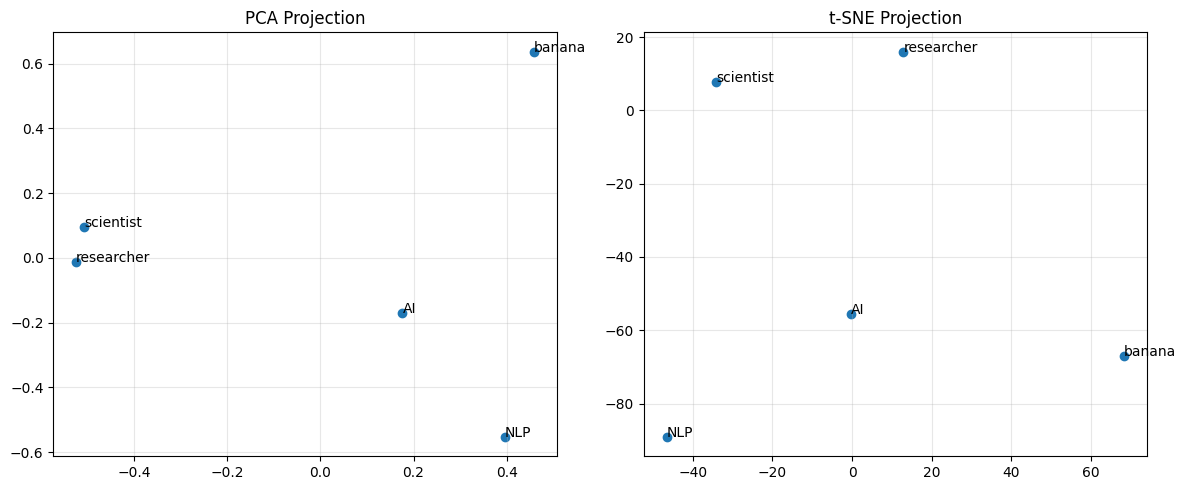

In [ ]:
## Try for ['cardiologist', 'heart specialist', 'myocardial infarction', 'heart attack', 'banana']
# =========================================================
# PCA vs t-SNE Comparison of Embeddings
# =========================================================

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ---------- PCA ----------
pca = PCA(n_components=2)
emb_pca = pca.fit_transform(embeddings)

# ---------- t-SNE ----------
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=3   # important for small sample size
)
emb_tsne = tsne.fit_transform(embeddings)

# ---------- Plot side-by-side ----------
plt.figure(figsize=(12,5))

# ----- PCA subplot -----
plt.subplot(1,2,1)
plt.scatter(emb_pca[:,0], emb_pca[:,1])

for i, word in enumerate(words):
    plt.text(emb_pca[i,0], emb_pca[i,1], word)

plt.title("PCA Projection")
plt.grid(alpha=0.3)

# ----- t-SNE subplot -----
plt.subplot(1,2,2)
plt.scatter(emb_tsne[:,0], emb_tsne[:,1])

for i, word in enumerate(words):
    plt.text(emb_tsne[i,0], emb_tsne[i,1], word)

plt.title("t-SNE Projection")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Cosine similarity is a metric that measures how similar two vectors are based on the angle between them, rather than their magnitude. It is widely used in NLP to compare embeddings produced by models like Sentence-BERT.

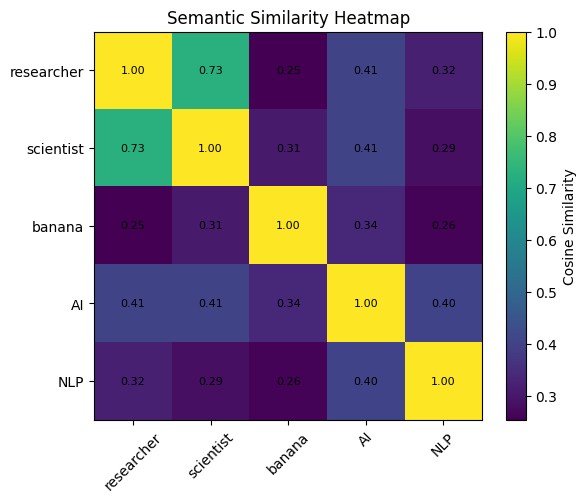

In [ ]:
##Try ['cardiologist', 'heart specialist', 'myocardial infarction', 'heart attack', 'banana']
plt.figure(figsize=(6,5))
plt.imshow(sim)
plt.colorbar(label="Cosine Similarity")

plt.xticks(range(len(words)), words, rotation=45)
plt.yticks(range(len(words)), words)

# add numeric values inside cells
for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, f"{sim[i,j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Semantic Similarity Heatmap")
plt.tight_layout()
plt.show()

### Task 2 — Semantic Similarity Analysis

1. Closest Pair: Which pair of words has the highest semantic similarity (excluding self-similarity)?

Write the pair: __________

2. Outlier Detection: Which word appears most semantically different from the others?

Write the word: __________

3. Cluster Observation: From the visualization (PCA or t-SNE), identify:

*  one pair of words that forms a semantic cluster
*  one word that is isolated

Cluster pair: __________
Isolated word: __________

## 🔹 3. Self-Attention Intuition
Self-attention is the core mechanism in Transformers that allows each token in a sequence to dynamically focus on the most relevant other tokens when building its representation.

Concept: “For this word, which other words in the sentence matter most?”
e.g. The doctor prescribed medicine because *she* was sick.

To understand “she”, the model should attend strongly to:
* doctor (less likely) - Wrong
* medicine - Wrong
* sick  - Wrong
* patient / implicit subject context - Correct

Self-attention learns these dependencies automatically.

In [ ]:
# =========================================================
# Imports for Attention Demo
# =========================================================

import torch                      # tensor operations
import numpy as np                # numerical utilities
import torch.nn.functional as F   # softmax for attention

In [ ]:
import torch.nn.functional as F
# Import PyTorch functional API for softmax operation used in attention

tokens = ['I', 'am', 'an', 'NLP', 'researcher'] ## Try: 1) Patient has high fever and headache. 2) Patient has fever for 3 days and severe headaches.
# Example token sequence (for interpretability only)

x = torch.randn(len(tokens), 8)
# Create random embeddings for each token
# Shape: (number_of_tokens, embedding_dimension=8)
# This simulates token representations coming from an embedding layer

Q = x; K = x; V = x
# In self-attention, Query, Key, and Value are projections of the same input
# Here we use the same tensor for simplicity (toy demonstration)

scores = torch.matmul(Q, K.T) / np.sqrt(8)
# Compute scaled dot-product attention scores
# Step 1: QK^T → similarity between each pair of tokens
# Step 2: divide by sqrt(d_k) to stabilize gradients
# Result shape: (num_tokens, num_tokens)

weights = F.softmax(scores, dim=-1)
# Apply softmax row-wise to convert scores into attention probabilities
# Each row now sums to 1
# These represent how much each token attends to others

print('Attention Weights:\n', weights)
# Display the attention weight matrix

Attention Weights:
 tensor([[0.9702, 0.0094, 0.0013, 0.0177, 0.0015],
        [0.1345, 0.7373, 0.0337, 0.0594, 0.0351],
        [0.0166, 0.0304, 0.9300, 0.0175, 0.0055],
        [0.2487, 0.0583, 0.0190, 0.5811, 0.0929],
        [0.0037, 0.0062, 0.0011, 0.0167, 0.9723]])


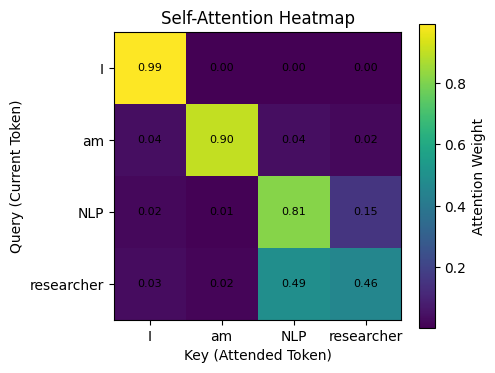

In [ ]:
# =========================================================
# Visualization: Self-Attention Heatmap
# =========================================================

import matplotlib.pyplot as plt

# Convert tensor to numpy for plotting
attn = weights.detach().numpy()

# Create figure FIRST (important!)
plt.figure(figsize=(5,4))

# Plot heatmap
plt.imshow(attn)

# Add color bar to show attention strength
plt.colorbar(label="Attention Weight")

# Label axes with tokens
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)

# Axis titles
plt.xlabel("Key (Attended Token)")
plt.ylabel("Query (Current Token)")

# Add numeric values inside each cell
for i in range(len(tokens)):
    for j in range(len(tokens)):
        plt.text(j, i, f"{attn[i,j]:.2f}",
                 ha="center", va="center", fontsize=8)

# Title
plt.title("Self-Attention Heatmap")

plt.tight_layout()
plt.show()

## Multi-head Attention
Multi-Head Attention (MHA) extends self-attention by running multiple attention mechanisms in parallel, allowing the model to capture different types of relationships simultaneously.

* One head = one perspective
* Multiple heads = multiple perspectives

Different heads may learn to focus on:

* Head 1 → coreference (“she” → cardiologist)
* Head 2 → subject–verb relation
* Head 3 → medical semantic similarity
* Head 4 → positional proximity

In [ ]:
# =========================================================
# Multi-Head Attention Simulation
# =========================================================

import torch
# PyTorch: used for tensor creation and matrix operations

import numpy as np
# NumPy: used here for the square-root scaling factor

import torch.nn.functional as F
# Functional API: provides softmax for attention normalization

import matplotlib.pyplot as plt
# Matplotlib: will be used later for visualizing attention heads


tokens = ['I', 'am', 'NLP', 'researcher']
# Example token sequence (only for labeling and interpretability)


num_heads = 3
# Number of attention heads to simulate
# Real transformers use many heads (e.g., 12 in BERT-base)

d_model = 8
# Embedding dimension for each token (toy size for demo)

d_k = d_model
# Key dimension used in scaling factor
# In real transformers: d_k = d_model / num_heads


heads = []
# This list will store the attention matrix from each head


for h in range(num_heads):
    # Loop over each attention head
    # Each head learns a different attention pattern

    # -----------------------------------------------------
    # Simulate token embeddings for this head
    # -----------------------------------------------------
    x = torch.randn(len(tokens), d_model)
    # Random tensor simulating token representations
    # Shape: (num_tokens, embedding_dim)

    Q = x
    K = x
    V = x
    # In self-attention, Query, Key, and Value come from the same input
    # Here we reuse x for simplicity (toy example)
    # In real transformers, these are separate learned projections

    # -----------------------------------------------------
    # Compute scaled dot-product attention scores
    # -----------------------------------------------------
    scores = torch.matmul(Q, K.T) / np.sqrt(d_k)
    # Step 1: QK^T computes similarity between tokens
    # Step 2: divide by sqrt(d_k) to stabilize gradients
    # Result shape: (num_tokens, num_tokens)

    # -----------------------------------------------------
    # Convert scores to attention probabilities
    # -----------------------------------------------------
    weights = F.softmax(scores, dim=-1)
    # Softmax applied row-wise
    # Each row now sums to 1 (probability distribution)

    # -----------------------------------------------------
    # Store this head's attention matrix
    # -----------------------------------------------------
    heads.append(weights.detach().numpy())
    # detach(): remove from computation graph
    # numpy(): convert to NumPy for plotting later

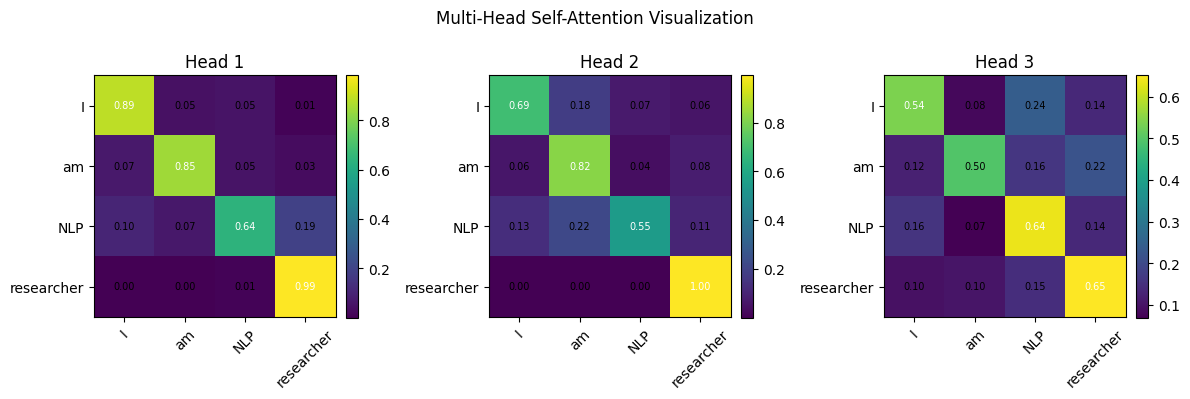

In [ ]:
# =========================================================
# Plot Multi-Head Attention Heatmaps (with numeric values)
# =========================================================

plt.figure(figsize=(12,4))
# Create a wide figure for multiple heads

for h in range(num_heads):
    # Loop over each attention head

    plt.subplot(1, num_heads, h+1)
    # Create subplot for current head

    plt.imshow(heads[h])
    # Show heatmap for this head

    plt.title(f"Head {h+1}")

    plt.xticks(range(len(tokens)), tokens, rotation=45)
    plt.yticks(range(len(tokens)), tokens)

    # Add numeric values inside each cell
    for i in range(len(tokens)):
        for j in range(len(tokens)):
            value = heads[h][i, j]

            # Auto-contrast text color for readability
            color = "white" if value > 0.5 else "black"

            plt.text(j, i, f"{value:.2f}",
                     ha="center", va="center",
                     fontsize=7, color=color)

    plt.colorbar(fraction=0.046, pad=0.04)

plt.suptitle("Multi-Head Self-Attention Visualization")
plt.tight_layout()
plt.show()

## Multihead Attention Observation
Head 1 — Mostly identity attention

* Very sharp diagonal dominance.
* Minimal cross-token interaction.
* Behaves like a position-preserving head.
* Often seen in some Transformer heads that act as “copy heads.”

Head 2 — Mild contextual mixing
* Still diagonal-heavy.
* Slight attention spreading:
* NLP → am and I have small weights.
* Shows early contextual awareness.
* Beginning to model token relationships.

Head 3 — Strongest contextual behavior
* This head shows the most distributed attention:
* More off-diagonal mass.
* Tokens attend to neighbors more.
* Less extreme self-focus.

Example patterns:
1. I attends partly to NLP
2. am spreads attention across tokens
3. researcher distributes attention more than in other heads

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


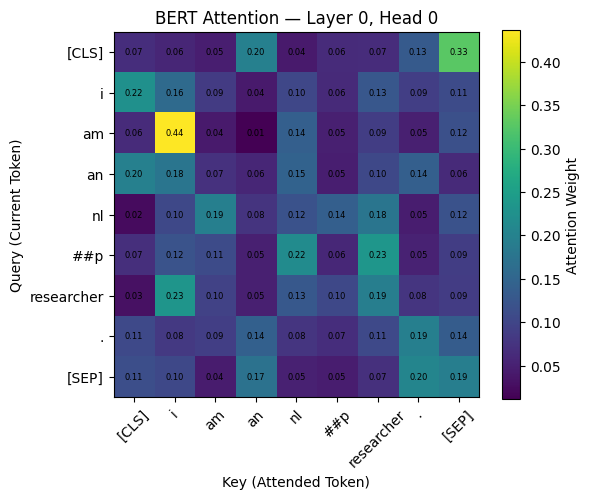

In [ ]:
# =========================================================
# Real BERT Attention Visualization
# =========================================================

import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

model = AutoModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True  # ⭐ IMPORTANT: enables attention extraction
)

model.eval()

sentence = "I am an NLP researcher."

# Tokenize input
inputs = tokenizer(sentence, return_tensors="pt")

# Run model forward pass
with torch.no_grad():
    outputs = model(**inputs)

# Extract attention tensors
attentions = outputs.attentions

layer = 0
head = 0

attn = attentions[layer][0, head].numpy()
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

plt.figure(figsize=(6,5))

plt.imshow(attn)
plt.colorbar(label="Attention Weight")

plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.yticks(range(len(tokens)), tokens)

plt.xlabel("Key (Attended Token)")
plt.ylabel("Query (Current Token)")
plt.title(f"BERT Attention — Layer {layer}, Head {head}")

# add numeric values (optional but impressive)
for i in range(len(tokens)):
    for j in range(len(tokens)):
        val = attn[i, j]
        color = "white" if val > 0.5 else "black"
        plt.text(j, i, f"{val:.2f}",
                 ha="center", va="center", fontsize=6, color=color)

plt.tight_layout()
plt.show()

## Task 3
Visualize the attention distributions produced by single-head and multi-head self-attention mechanisms for the given sentence. Compare the attention patterns and observe how multiple heads capture different contextual relationships between tokens.

## 🔹 4. Prompt Engineering

Prompt engineering is the practice of designing and structuring inputs to large language models (LLMs) so they produce accurate, relevant, and controllable outputs.

Concept: “How should I ask the model to get the best possible response?”

In [ ]:
from transformers import pipeline

# Load generator
generator = pipeline('text-generation', model='gpt2')

# ---------- Weak prompt ----------
weak_prompt = 'Explain diabetes.'

# ---------- Strong prompt ----------
strong_prompt = (
    'Explain Type 2 diabetes in exactly 3 bullet points '
    'for a non-medical audience. Use simple language.'
)

print('Weak Prompt Output:\n')
print(generator(weak_prompt, max_length=80, do_sample=True)[0]['generated_text'])

print('\n' + '='*50 + '\n')

print('Strong Prompt Output:\n')
print(generator(strong_prompt, max_length=80, do_sample=True)[0]['generated_text'])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Weak Prompt Output:



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Explain diabetes.

When people are diagnosed with diabetes, the liver is the most important organ in their body, and the body will treat it in many ways. Although the liver does not have a specific function, it is the most important organ that the body needs to treat diabetes.

Diabetes is an autoimmune disease, which happens when your body is unable to fight the disease. This can cause problems with your health and your ability to live a healthy lifestyle. In the past, a health care provider may have to explain the symptoms of diabetes to you, and they might even ask you what you thought of those symptoms.

In the future, a diagnosis of diabetes may be different in people with different immune systems. In some patients, it may also be possible to use a combination of insulin and a treatment known as insulin resistance. Although most people with diabetes do not have the health problems diagnosed with diabetes, some people with diabetes also have some of the symptoms of diabetes.


Stro

In [ ]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="gpt2",
    model_kwargs={"pad_token_id": 50256}
)

def generate_text(prompt):
    return generator(
        prompt,
        max_new_tokens=60,
        do_sample=True,
        return_full_text=True
    )[0]["generated_text"]

# Prompts
weak_prompt = "Explain diabetes."

strong_prompt = (
    "Explain Type 2 diabetes in exactly 3 bullet points "
    "for a non-medical audience. Use simple language."
)

print("Weak Prompt Output:\n")
print(generate_text(weak_prompt))

print("\n" + "="*50 + "\n")

print("Strong Prompt Output:\n")
print(generate_text(strong_prompt))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Weak Prompt Output:



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Explain diabetes.

And there's a reason why a lot of people who have diabetes respond well to the same drugs. They're not having a bad day. And they're not having to pay for the medications they're taking.

The same thing is happening with diabetes. And if you have diabetes,


Strong Prompt Output:

Explain Type 2 diabetes in exactly 3 bullet points for a non-medical audience. Use simple language. Ask how much your body is able to handle. Get a baseline of glucose and insulin levels. Ask if your blood sugar is normal. Ask if your fasting glucose level is normal. Ask if your insulin level is normal. Ask if your blood sugar is normal. Ask if your body is able to handle


## Observation:
GPT-2 is not instruction-tuned model. So, weak prompt is rambling and storng prompt tried but fails.

## Task 4 — Instruction-Tuned Model Comparison
Goal: Evaluate how different instruction-tuned models respond to:

1. a weak prompt
2. a strongly engineered prompt

and analyze instruction-following capability.

Models to Test
* google/flan-t5-base
* google/flan-t5-large
* (optional GPU) microsoft/Phi-3-mini-4k-instruct

1. weak_prompt = "Explain diabetes."
2. strong_prompt =
    * "Task: Explain Type 2 diabetes.\n"
    * "Audience: non-medical readers.\n"
    * "Write EXACTLY three bullet points.\n"
    * "Use simple language.\n"
    * "Answer:\n"
    * "- "

## 🔹 5. In-Context Learning
Goal: Teach the model the task pattern using examples inside the prompt — without updating model weights.

In [ ]:
# Core libraries for instruction-tuned models
!pip install -q transformers accelerate sentencepiece torch

In [ ]:
# Define a few-shot in-context learning prompt for English → Hindi translation
prompt = '''English to Hindi:
one -> एक
two -> दो
three ->'''  # The model should infer the pattern and complete the translation for "three"

# Print the constructed prompt so we can verify what will be sent to the model
print(prompt)

# Print the expected correct translation for evaluation/reference purposes
print('\nExpected answer: तीन')

English to Hindi:
one -> एक
two -> दो
three ->

Expected answer: तीन


In [ ]:
# ======================================
# 1. Imports
# ======================================
from transformers import pipeline, set_seed

set_seed(42)

# ======================================
# 2. Load a small language model
# (GPT-2 works for demonstration)
# ======================================
generator = pipeline(
    "text-generation",
    model="gpt2",
    pad_token_id=50256
)

# ======================================
# 3. Define few-shot prompt
# ======================================
prompt = """English to Hindi:
one -> एक
two -> दो
three ->"""

print("===== PROMPT =====\n")
print(prompt)

# Ground-truth answer (for evaluation)
gold_answer = "तीन"
print("\nExpected answer:", gold_answer)

# ======================================
# 4. Generate model output
# ======================================
output = generator(
    prompt,
    max_new_tokens=5,
    do_sample=False  # deterministic for teaching
)[0]["generated_text"]

print("\n===== RAW MODEL OUTPUT =====\n")
print(output)

# ======================================
# 5. Extract model prediction
# ======================================
# Take text after the last arrow
predicted = output.split("->")[-1].strip().split("\n")[0]

print("\nModel predicted:", predicted)

# ======================================
# 6. Automatic correctness check
# ======================================
is_correct = gold_answer in predicted

print("\n===== RESULT =====")
print("Correct?" , is_correct)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


===== PROMPT =====

English to Hindi:
one -> एक
two -> दो
three ->

Expected answer: तीन

===== RAW MODEL OUTPUT =====

English to Hindi:
one -> एक
two -> दो
three -> दो


Model predicted: दो

===== RESULT =====
Correct? False


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ======================================
# Load FLAN-T5 properly
# ======================================
model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# ======================================
# Your same prompt
# ======================================
prompt = """English to Hindi:
one -> एक
two -> दो
three ->"""

print("===== PROMPT =====\n")
print(prompt)

gold_answer = "तीन"
print("\nExpected answer:", gold_answer)

# ======================================
# Generate
# ======================================
inputs = tokenizer(prompt, return_tensors="pt")

outputs = model.generate(
    **inputs,
    max_new_tokens=5
)

decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("\n===== FLAN-T5 OUTPUT =====\n")
print(decoded)

# ======================================
# Simple correctness check
# ======================================
is_correct = gold_answer in decoded
print("\nCorrect?", is_correct)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


===== PROMPT =====

English to Hindi:
one -> एक
two -> दो
three ->

Expected answer: तीन

===== FLAN-T5 OUTPUT =====

  

Correct? False


### Task 5
Evaluate how different LLMs respond to:

*  Zero-shot prompting
*  One-shot prompting
*  Few-shot prompting

and compare their generalization ability.

## 🔹 6. Mini RAG Demo

In [ ]:
# =====================================================
# Step 0: (Run once if needed)
# =====================================================
# !pip install -q sentence-transformers scikit-learn transformers

# =====================================================
# Step 1: Import libraries
# =====================================================
from sentence_transformers import SentenceTransformer  # for dense embeddings
from sklearn.metrics.pairwise import cosine_similarity  # for similarity search
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM  # generator model

# =====================================================
# Step 2: Build a small knowledge base
# =====================================================
docs = [
    "Dengue symptoms include high fever, headache, and joint pain.",
    "Malaria symptoms include fever and chills.",
    "Diabetes is a metabolic disorder related to blood sugar."
]

# User query
query = "What are symptoms of dengue?"

# =====================================================
# Step 3: Load embedding model (Retriever)
# =====================================================
# This model converts text → dense vectors
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode documents into vectors
doc_emb = embed_model.encode(docs)

# Encode the user query
query_emb = embed_model.encode([query])

# =====================================================
# Step 4: Retrieve most similar document
# =====================================================
# Compute cosine similarity between query and documents
scores = cosine_similarity(query_emb, doc_emb)[0]

# Select the highest scoring document
best_doc = docs[scores.argmax()]

print("Retrieved context:\n", best_doc)

# =====================================================
# Step 5: Load generator model (FLAN-T5)
# =====================================================
# Instruction-tuned model works better than GPT-2 for RAG
model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
gen_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# =====================================================
# Step 6: Build the RAG prompt
# =====================================================
# The LLM will use retrieved context to answer the question
rag_prompt = f"""Use the context to answer the question.

Context: {best_doc}

Question: {query}
Answer:"""

print("\nRAG Prompt:\n", rag_prompt)

# =====================================================
# Step 7: Generate grounded answer
# =====================================================
inputs = tokenizer(rag_prompt, return_tensors="pt")

outputs = gen_model.generate(
    **inputs,
    max_new_tokens=40,   # limit answer length
    do_sample=False      # deterministic for demos
)

# Decode model output into readable text
answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("\nRAG Answer:\n", answer)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Retrieved context:
 Dengue symptoms include high fever, headache, and joint pain.


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



RAG Prompt:
 Use the context to answer the question.

Context: Dengue symptoms include high fever, headache, and joint pain.

Question: What are symptoms of dengue?
Answer:

RAG Answer:
 high fever, headache, and joint pain


In [ ]:
# What document was retrieved?
print(best_doc)

Dengue symptoms include high fever, headache, and joint pain.


In [ ]:
# =====================================================
# Step 0: Install (run once if needed)
# =====================================================
# !pip install -q sentence-transformers scikit-learn transformers

# =====================================================
# Step 1: Imports
# =====================================================
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import numpy as np

# =====================================================
# Step 2: Knowledge Base (larger than before)
# =====================================================
docs = [
    "Dengue symptoms include high fever, headache, and joint pain.",
    "Malaria symptoms include fever, chills, and sweating.",
    "Common cold symptoms include sneezing and sore throat.",
    "Diabetes is a metabolic disorder related to blood sugar levels.",
    "Typhoid symptoms include prolonged fever and weakness."
]

query = "What are the symptoms of dengue?"

# =====================================================
# Step 3: Load embedding model (Retriever)
# =====================================================
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode documents and query
doc_emb = embed_model.encode(docs)
query_emb = embed_model.encode([query])

# =====================================================
# Step 4: Top-K Retrieval (IMPORTANT UPGRADE)
# =====================================================
top_k = 2  # retrieve top 2 relevant documents

scores = cosine_similarity(query_emb, doc_emb)[0]

# Get indices of top-k documents (highest similarity first)
top_indices = np.argsort(scores)[-top_k:][::-1]

# Collect retrieved contexts
retrieved_docs = [docs[i] for i in top_indices]

print("Top-K Retrieved Contexts:")
for i, doc in enumerate(retrieved_docs, 1):
    print(f"{i}. {doc}")

# Combine contexts into one block
context_block = "\n".join(retrieved_docs)

# =====================================================
# Step 5: Load generator (FLAN-T5)
# =====================================================
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
gen_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# =====================================================
# Step 6: Build improved RAG prompt
# =====================================================
rag_prompt = f"""Use the following medical context to answer the question.

Context:
{context_block}

Question: {query}
Answer:"""

print("\n RAG Prompt:\n", rag_prompt)

# =====================================================
# Step 7: Generate grounded answer
# =====================================================
inputs = tokenizer(rag_prompt, return_tensors="pt")

outputs = gen_model.generate(
    **inputs,
    max_new_tokens=50,
    do_sample=False
)

answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("\n RAG Answer:\n", answer)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Top-K Retrieved Contexts:
1. Dengue symptoms include high fever, headache, and joint pain.
2. Malaria symptoms include fever, chills, and sweating.


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



 RAG Prompt:
 Use the following medical context to answer the question.

Context:
Dengue symptoms include high fever, headache, and joint pain.
Malaria symptoms include fever, chills, and sweating.

Question: What are the symptoms of dengue?
Answer:

 RAG Answer:
 high fever, headache, and joint pain


Questions:
1. Does RAG reduce hallucination?
2. Does top-k affect answer quality?
3. Why structured prompts help?

## Task 6
Build a simple RAG pipeline for the given medical queries. Retrieve the most relevant documents using embeddings and generate grounded answers using an instruction-tuned model. Compare the responses with and without retrieval.

1. Retrieval Quality
* Are the retrieved documents relevant to the query?
* Does increasing top-k improve or hurt relevance?

2. RAG vs Non-RAG
Compare answers:
* Which response is more factual?
* Which response is more specific?
* Does RAG reduce hallucination?
Write observation: __________

3. Context Utilization
* Does the model actually use the retrieved context?
* Is the answer grounded in the provided text?
* Write observation: __________